# Banking FAQ Semantic Search System

## Objective

Build a semantic search engine for banking FAQs using:

- Sentence Transformers
- Embeddings
- Cosine Similarity
- Semantic Retrieval

This notebook will:
- generate semantic embeddings
- retrieve most relevant banking FAQs
- compare semantic similarity
- prepare for FAISS Vector Database
- prepare for RAG pipeline

---

## Technologies Used

- Python
- Pandas
- Sentence Transformers
- Scikit-learn
- NumPy
- Cosine Similarity

### Import Libraries

In [1]:
# Data Handling
import pandas as pd
import numpy as np

# NLP Embeddings
from sentence_transformers import SentenceTransformer

# Similarity Search
from sklearn.metrics.pairwise import cosine_similarity

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings
import warnings
warnings.filterwarnings("ignore")

### Load Processed Dataset

In [3]:
# Load Processed Dataset

df = pd.read_csv("../data/processed_data/banking_processed.csv")

# Display First 5 Rows
df.head()

,Section,Question,Answer,question_length,answer_length,clean_question,processed_question,label
0,Financial Markets,Give me details about mcx.,"Generally, MCX (Multi Commodity Exchange) is I...",26,179,give detail mcx,give me details about mcx,4
1,Basic Accounts,Can you explain an account opening bonus?,"From a banking perspective, Some banks offer c...",41,147,explain account opening bonus,can you explain an account opening bonus,1
2,General Finance,Tell me about real estate investment.,"In simple words, Real estate investing means b...",37,160,tell real estate investment,tell me about real estate investment,5
3,Customer Service,How does how do i avoid sim swap fraud work?,"Generally, Never share your mobile number or A...",44,169,avoid sim swap fraud work,how does how do i avoid sim swap fraud work,2
4,Customer Service,Give me details about how do i apply for a cre...,"Generally, Apply on the bank's website, throug...",55,170,give detail apply credit card,give me details about how do i apply for a cre...,2


### Basic Dataset Inspection

#### Dataset Shape

In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (127930, 8)


#### Column Names

In [5]:
df.columns

Index(['Section', 'Question', 'Answer', 'question_length', 'answer_length',
       'clean_question', 'processed_question', 'label'],
      dtype='object')

#### Keep Required Columns Only

In [9]:
df = df[[
    "Section",
    "Question",
    "Answer",
    "processed_question"
]]

# Display First 5 Rows
df.head()

,Section,Question,Answer,processed_question
0,Financial Markets,Give me details about mcx.,"Generally, MCX (Multi Commodity Exchange) is I...",give me details about mcx
1,Basic Accounts,Can you explain an account opening bonus?,"From a banking perspective, Some banks offer c...",can you explain an account opening bonus
2,General Finance,Tell me about real estate investment.,"In simple words, Real estate investing means b...",tell me about real estate investment
3,Customer Service,How does how do i avoid sim swap fraud work?,"Generally, Never share your mobile number or A...",how does how do i avoid sim swap fraud work
4,Customer Service,Give me details about how do i apply for a cre...,"Generally, Apply on the bank's website, throug...",give me details about how do i apply for a cre...


#### Dataset Info

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 127930 entries, 0 to 127929
Data columns (total 4 columns):
 #   Column              Non-Null Count   Dtype 
---  ------              --------------   ----- 
 0   Section             127930 non-null  object
 1   Question            127930 non-null  object
 2   Answer              127930 non-null  object
 3   processed_question  127930 non-null  object
dtypes: object(4)
memory usage: 3.9+ MB


### Missing Values & Duplicates

#### Missing Values

In [11]:
df.isnull().sum()

Section               0
Question              0
Answer                0
processed_question    0
dtype: int64

#### Duplicate Rows

In [12]:
df.duplicated(subset=["Question"]).sum()

0

### Create Search Corpus

#### Create combined text

In [14]:
corpus = df["processed_question"].tolist()

# Display Sample Questions
corpus[:10]

['give me details about mcx',
 'can you explain an account opening bonus',
 'tell me about real estate investment',
 'how does how do i avoid sim swap fraud work',
 'give me details about how do i apply for a credit card',
 'how can i understand a moratorium period',
 'can you explain the interbank rate',
 'what do you mean by tier 1 capital',
 'tell me about indexation benefit',
 'what is the meaning of the charge for atm transactions beyond the free limit']

### Load Sentence Transformer Model

##### Why Sentence Transformers?

Traditional TF-IDF:
- matches keywords
- fails on semantic meaning

Sentence Transformers:
- understand context
- understand meaning
- generate semantic embeddings

Example:

| Query 1 | Query 2 |
|---|---|
| What is EMI? | Explain loan installment |

Sentence embeddings understand both mean the same thing.

In [16]:
embedding_model = SentenceTransformer(
    "sentence-transformers/all-MiniLM-L6-v2"
)

print("Embedding model loaded successfully.")

Embedding model loaded successfully.


### Generate Embeddings

The embedding model converts each banking FAQ into a dense numerical vector.

These vectors capture:
- semantic meaning
- contextual similarity
- banking terminology relationships

In [17]:
question_embeddings = embedding_model.encode(
    corpus,
    show_progress_bar=True
)

# Shape
print("Embeddings Shape:", question_embeddings.shape)

Batches:   0%|          | 0/3998 [00:00<?, ?it/s]

Embeddings Shape: (127930, 384)


In [18]:
# Check Embedding Vector Example
question_embeddings[0]

array([-1.73571277e-02, -5.89455999e-02,  6.28744289e-02, -9.31029115e-03,
        1.46924453e-02, -3.11014894e-03,  5.31430393e-02,  7.15573430e-02,
       -4.29780520e-02,  1.14572207e-02, -8.20873119e-03,  3.15619707e-02,
        6.77867532e-02,  8.44116323e-04, -1.92557815e-02, -6.48271292e-02,
        3.67170945e-02,  3.55871720e-03,  7.79132731e-03, -7.18706637e-04,
        5.86109608e-02, -8.00157115e-02, -3.14260870e-02, -3.30862729e-03,
       -1.19494267e-01,  7.34071285e-02,  1.06275387e-01, -4.89771785e-03,
        4.21101600e-03, -7.70500377e-02,  3.65465395e-02,  9.93140116e-02,
        7.26188421e-02, -5.95515259e-02,  3.01086009e-02,  5.92477284e-02,
        1.88868493e-02,  1.66469347e-02, -6.15524463e-02, -8.05033594e-02,
       -2.47203484e-02, -4.64866050e-02,  1.34871513e-01,  8.28983635e-03,
        4.37845960e-02, -8.32704976e-02,  8.79183970e-03, -9.19114426e-02,
        3.60390656e-02,  8.32192227e-02, -2.33358461e-02, -9.55723822e-02,
        1.56487618e-02,  

#### Understanding Embeddings

##### What are Embeddings?

Embeddings are dense numerical vector representations of text.

Instead of:
```text
"What is EMI?"
```

the model converts the sentence into:
```text
[0.12, -0.55, 0.91, ...]
```

Similar sentences produce similar vectors.

This enables:
- semantic search
- recommendation systems
- RAG pipelines
- chatbot retrieval

#### Check Embedding Shape

In [19]:
print("Total Questions:", len(question_embeddings))

print("Embedding Dimension:", len(question_embeddings[0]))

Total Questions: 127930
Embedding Dimension: 384


### Semantic Search Function

This function:
- converts query into embedding
- calculates cosine similarity
- retrieves top-k most similar banking FAQs

In [20]:
def semantic_search(
    query,
    top_k=5
):

    # Query Embedding
    query_embedding = embedding_model.encode([query])

    # Cosine Similarity
    similarity_scores = cosine_similarity(
        query_embedding,
        question_embeddings
    )[0]

    # Top Indices
    top_indices = np.argsort(
        similarity_scores
    )[-top_k:][::-1]

    # Results
    results = []

    for idx in top_indices:

        results.append({

            "Question":
            df.iloc[idx]["Question"],

            "Answer":
            df.iloc[idx]["Answer"],

            "Section":
            df.iloc[idx]["Section"],

            "Similarity Score":
            round(similarity_scores[idx], 4)
        })

    return pd.DataFrame(results)

#### Test Semantic Search

In [21]:
# Example Query 1
query = "How can I transfer money internationally?"

results = semantic_search(
    query=query,
    top_k=5
)

results

,Question,Answer,Section,Similarity Score
0,Give me details about how do i transfer money ...,"Use NEFT, RTGS, or IMPS through your mobile ba...",Customer Service,0.7304
1,How do I transfer money to another bank?,"Use NEFT, RTGS, or IMPS through your mobile ba...",Customer Service,0.7271
2,I want to know about how do i transfer money t...,"Use NEFT, RTGS, or IMPS through your mobile ba...",Customer Service,0.7224
3,Tell me about how do i transfer money to anoth...,"Usually, Use NEFT, RTGS, or IMPS through your ...",Customer Service,0.7200
4,Can you tell me what how do i transfer money t...,"Basically, Use NEFT, RTGS, or IMPS through you...",Customer Service,0.7177


In [22]:
# Example Query 2
query = "How do EMI payments work?"

results = semantic_search(
    query=query,
    top_k=5
)

results

,Question,Answer,Section,Similarity Score
0,Could you explain how do i pay an emi early in...,Transfer the outstanding amount to your loan a...,Customer Service,0.8401
1,How does how do i pay an emi early in simple t...,"Basically, Transfer the outstanding amount to ...",Customer Service,0.8174
2,Explain the concept of How do I pay an EMI ear...,Transfer the outstanding amount to your loan a...,Customer Service,0.7985
3,Could you explain how do i pay an emi early?,"In banking terms, Transfer the outstanding amo...",Customer Service,0.7903
4,Explain the concept of How do I pay an EMI ear...,Transfer the outstanding amount to your loan a...,Customer Service,0.7897


#### Test Semantic Understanding

##### Semantic Search Advantage

Unlike TF-IDF:
- semantic search understands meaning
- not just exact words

Example:

Query:
```text
Explain online money transfer
```

Can retrieve:
- NEFT
- RTGS
- IMPS
- UPI

even if exact keywords differ.

### Similarity Score Analysis

Higher similarity scores indicate:
- stronger semantic relationship
- closer contextual meaning
- better banking FAQ relevance

In [23]:
query = "How can I open a savings account?"

query_embedding = embedding_model.encode([query])

similarities = cosine_similarity(
    query_embedding,
    question_embeddings
)[0]

print("Maximum Similarity:", similarities.max())
print("Minimum Similarity:", similarities.min())
print("Average Similarity:", similarities.mean())

Maximum Similarity: 0.7277477
Minimum Similarity: -0.14538676
Average Similarity: 0.17776804


#### Similarity Score Visualization

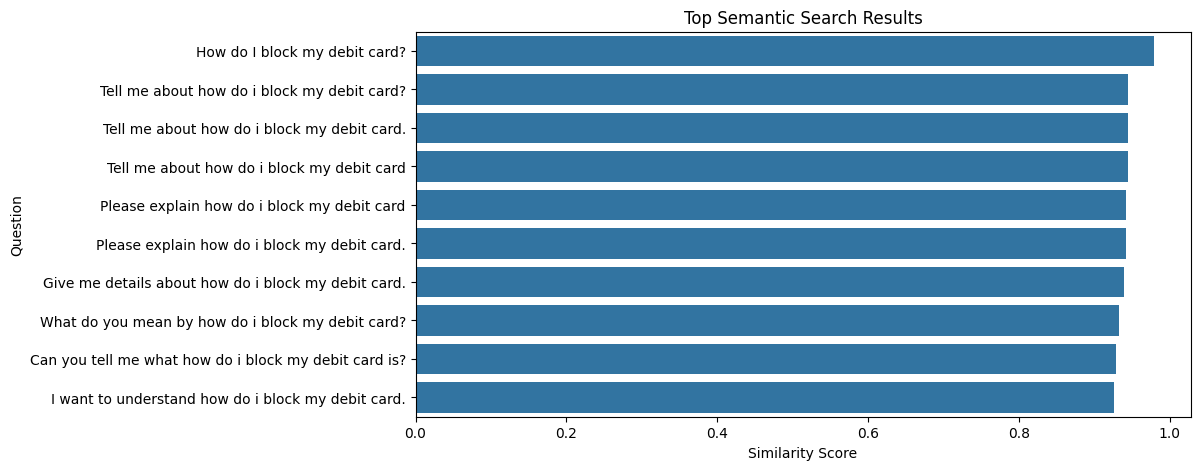

In [24]:
query = "How to block debit card?"

results = semantic_search(
    query=query,
    top_k=10
)

# Plot
plt.figure(figsize=(10,5))
sns.barplot(
    x="Similarity Score",
    y="Question",
    data=results
)
plt.title("Top Semantic Search Results")
plt.show()

## Advantages of Semantic Search

### TF-IDF vs Semantic Search

| TF-IDF | Semantic Search |
|---|---|
| keyword matching | meaning matching |
| sparse vectors | dense vectors |
| fails on paraphrases | handles paraphrases |
| lexical similarity | semantic similarity |
| traditional NLP | modern AI retrieval |

Semantic search is the foundation of:
- RAG systems
- AI assistants
- recommendation engines
- vector databases

# Current Limitations

Current semantic retrieval system still has some limitations:

- cosine similarity search is slow for very large datasets
- no vector indexing yet
- retrieval is memory-based
- no conversational memory
- no LLM integration yet

These limitations will be solved using:
- FAISS vector database
- LangChain
- RAG pipelines
- Groq LLM integration

### Save Embeddings

Embeddings are saved for:
- future FAISS indexing
- RAG pipelines
- semantic retrieval systems

In [25]:
np.save(
    "../models/embeddings/question_embeddings.npy",
    question_embeddings
)

print("Embeddings Saved Successfully")

Embeddings Saved Successfully


### Save Processed Semantic Dataset

In [26]:
df.to_csv(
    "../data/processed_data/semantic_search_data.csv",
    index=False
)

print("Semantic Search Dataset Saved Successfully")

Semantic Search Dataset Saved Successfully


### Save Embedding Model Name

In [27]:
model_name = "sentence-transformers/all-MiniLM-L6-v2"

print("Embedding Model Used:", model_name)

Embedding Model Used: sentence-transformers/all-MiniLM-L6-v2


### Real-Time Semantic Search Pipeline

In [28]:
def search_bank_faq(query, top_k=5):
    results = semantic_search(
        query=query,
        top_k=top_k
    )
    return results

### Final Testing

In [29]:
query = "What happens if I miss EMI payment?"

results = search_bank_faq(
    query=query,
    top_k=5
)

results

,Question,Answer,Section,Similarity Score
0,Help me understand how do i pay an emi early.,"Typically, Transfer the outstanding amount to ...",Customer Service,0.6743
1,Can you explain how do i pay an emi early?,"Usually, Transfer the outstanding amount to yo...",Customer Service,0.6705
2,Could you explain how do i pay an emi early?,"In banking terms, Transfer the outstanding amo...",Customer Service,0.6701
3,How can I understand how do i pay an emi early?,"Typically, Transfer the outstanding amount to ...",Customer Service,0.6670
4,Can you provide information about how do i pay...,"In banking terms, Transfer the outstanding amo...",Customer Service,0.6654


# Key Insights & Observations

## 1. Semantic Search Successfully Implemented

The project now supports:
- semantic retrieval
- contextual search
- embedding-based similarity matching

Unlike TF-IDF, semantic embeddings understand:
- sentence meaning
- contextual similarity
- paraphrased banking queries

---

# 2. Embedding Model Used

Model:
```text
sentence-transformers/all-MiniLM-L6-v2
```

Advantages:
- lightweight
- fast
- low memory usage
- ideal for laptops
- excellent semantic understanding

Embedding dimension:
```text
384
```

---

# 3. Semantic Retrieval Benefits

The system can now retrieve:
- related banking FAQs
- paraphrased questions
- semantically similar queries

Examples:
- "online money transfer"
- "send money digitally"
- "transfer funds online"

All retrieve similar banking answers.

---

# 4. Why Semantic Search Is Important

Semantic search is the foundation of:
- FAISS vector databases
- Retrieval-Augmented Generation (RAG)
- AI assistants
- Generative AI chatbots

This notebook prepares the project for:
- vector search
- retrieval pipelines
- LLM integration

---

# 5. Next Phase

Next notebook:
```text
06_faiss_vector_db.ipynb
```

Will implement:
- FAISS indexing
- fast vector retrieval
- scalable semantic search
- production-grade retrieval system